## HDFS DeepLog Anomaly Detection Experiment

This experiment focuses on training and evaluating the **DeepLog** sequence model for **anomaly detection** on the HDFS log dataset.

### I. Dataset and Source

* **Dataset:** HDFS (LogHub preprocessed)
* **Source Citation:** Wei Xu et al. (SOSP 2009), Jieming Zhu et al. (ISSRE 2023)

### II. Model: DeepLog (LSTM-based)

* **Architecture:** **LSTM-based sequence anomaly detector**
* **Hyperparameters:**
    * `embedding_dim`: 64
    * `hidden_dim`: 128
    * `num_layers`: 2
    * `dropout`: 0.3


### III. Task and Evaluation

* **Task:** **Next-Event Prediction** for Sequence-Based Anomaly Detection.
    * Anomalies detected using **Top-k Prediction** criteria.
    * `top_k`: 4
* **Evaluation Metrics:** Accuracy, Precision, Recall, F1 Score, and AUC.

### IV. Data Flow and Training

#### A. Preprocessing
* **Tokenization:** Log events are tokenized and mapped to **integer IDs** via a vocabulary.
* **Sequencing:** Log sequences are padded to the **95th percentile length** using a padding value of **0**.
* **Data Split:**
    * Train: 70%
    * Validation: 15%
    * Test: 15%

#### B. Training
* **Batch Size:** 64
* **Learning Rate:** 0.001
* **Epochs:** Up to 50, with **Early Stopping** (`patience=20`).
* **Device:** Auto-detected (mps/cpu).

### V. Artifacts

* **Model Checkpoint:** `../mdls/deeplog_checkpoint.pt`
* **Results:** `../results/hdfs_deeplog_results.json`


### 1. Setup and Imports

In [1]:
# Core imports
import numpy as np
import torch
import sys
from pathlib import Path
# Add project root to Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Import modules
from src.data.dataset import create_data_loaders
from src.models.deeplog import DeepLogModel
from src.engine.trainer import LogSeqTrainer
from src.utils.metrics import evaluate_model, print_metrics, save_experiment_results
from src.utils.data_loader import create_train_val_test_split, filter_normal_samples, load_loghub
from src.utils.visualizer import UniversalAnomalyVisualizer
from src.utils.seed import seed_everything

### 2. Load and Prepare Data

In [ ]:
# Define paths
DATA_DIR = '../../data/hdfs/preprocessed'
seed_everything(42)  # For reproducibility

In [3]:
X, y, vocab = load_loghub(DATA_DIR)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Events: {sorted(vocab.keys())[:10]}")  # See first 10

INFO:src.utils.data_loader:Loading data from LogHub preprocessing: ../../data/hdfs/preprocessed
INFO:src.utils.data_loader:Loaded data:
INFO:src.utils.data_loader:  - Sequences: (575061,)
INFO:src.utils.data_loader:  - Labels: (575061,)
INFO:src.utils.data_loader:  - Normal: 558223, Anomaly: 16838
INFO:src.utils.data_loader:  - Loaded vocabulary: 29 events


Vocab size: 29
Events: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18']


In [4]:
#  Split data (70/15/15)
splits = create_train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, random_state=42)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = splits['train'], splits['val'], splits['test']
X_train, y_train = filter_normal_samples(X_train, y_train, verbose=True)

INFO:src.utils.data_loader:Splitting data: train=0.7, val=0.15, test=0.15
INFO:src.utils.data_loader:Split complete:
INFO:src.utils.data_loader:  - Train: 402542 samples (11786 anomalies)
INFO:src.utils.data_loader:  - Val:   86259 samples (2526 anomalies)
INFO:src.utils.data_loader:  - Test:  86260 samples (2526 anomalies)
INFO:src.utils.data_loader:======================================================================
INFO:src.utils.data_loader:FILTERING TRAINING DATA FOR SEMI-SUPERVISED LEARNING
INFO:src.utils.data_loader:======================================================================
INFO:src.utils.data_loader:Original training size: 402542 samples
INFO:src.utils.data_loader:  Normal samples: 390,756 (97.07%)
INFO:src.utils.data_loader:  Anomaly samples: 11,786 (2.93%)
INFO:src.utils.data_loader:
Filtered training size: 390,756 samples (NORMAL ONLY)
INFO:src.utils.data_loader:Removed 11,786 anomalies from training set
INFO:src.utils.data_loader:✓ Training data is now pure no

In [5]:
#  Convert strings to integers
def convert_to_ids(sequences, vocab):
    return [[vocab[event] for event in seq] for seq in sequences]

X_train_ids = convert_to_ids(X_train, vocab)
X_val_ids = convert_to_ids(X_val, vocab)
X_test_ids = convert_to_ids(X_test, vocab)

In [ ]:
# pad sequences (integers, not strings!)
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore

max_len = int(np.percentile([len(s) for s in X_train_ids], 95)) # todo try 64

X_train_padded = pad_sequences(X_train_ids, maxlen=max_len, padding='post', value=0)
X_val_padded = pad_sequences(X_val_ids, maxlen=max_len, padding='post', value=0)
X_test_padded = pad_sequences(X_test_ids, maxlen=max_len, padding='post', value=0)

print(f"Max length: {max_len}")
print(f"Train shape: {X_train_padded.shape}")

Max length: 28
Train shape: (390756, 28)


In [ ]:
# Get optimal dataloader kwargs
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
loader_kwargs = LogSeqTrainer.get_optimal_dataloader_kwargs(device)
loader_kwargs

{'pin_memory': False, 'num_workers': 4}

In [8]:
# Create data loaders

batch_size = 64
train_loader, val_loader, test_loader = create_data_loaders(
    X_train_padded, y_train,
    X_val_padded, y_val,
    X_test_padded, y_test,
    batch_size=batch_size,
    **loader_kwargs
)

### 3. Create Model

In [9]:
#  Create model
model = DeepLogModel(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3 
)

print(model)

DeepLogModel(
  (embedding): Embedding(29, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=29, bias=True)
)


### 4. Train

In [10]:
# Train
print(f"Training on {device} device.")
learning_rate = 0.001
trainer = LogSeqTrainer(model, device=device, learning_rate=learning_rate)
patience = 10
history = trainer.fit(
    train_loader, val_loader,
    num_epochs=50,
    early_stopping_patience=patience,
    print_every=5
)

Training on mps device.


Training: 100%|██████████| 6106/6106 [00:29<00:00, 208.59it/s]



Epoch 1/50 - 37.63s
  Train Loss: 0.2390
  Val Loss:   0.2382
  ✓ New best model (val_loss: 0.2382)


Training: 100%|██████████| 6106/6106 [00:28<00:00, 217.71it/s]



Epoch 5/50 - 35.87s
  Train Loss: 0.2116
  Val Loss:   0.2338
  ✓ New best model (val_loss: 0.2338)


...


Epoch 10/50 - 35.90s
  Train Loss: 0.2107
  Val Loss:   0.2332
  ✓ New best model (val_loss: 0.2332)


Training: 100%|██████████| 6106/6106 [00:27<00:00, 218.66it/s]



Epoch 15/50 - 35.75s
  Train Loss: 0.2102
  Val Loss:   0.2345
  No improvement (5/10)


Training: 100%|██████████| 6106/6106 [00:27<00:00, 218.46it/s]



Epoch 20/50 - 35.61s
  Train Loss: 0.2100
  Val Loss:   0.2345
  No improvement (10/10)

Early stopping triggered after 20 epochs

✓ Loaded best model (val_loss: 0.2332)
Total training time: 718.52s


### 5. Evaluation

In [11]:
# Evaluate
# Capture predictions, true labels, AND anomaly scores from the loader
top_k = 4                                                                       
predictions, true_labels, anomaly_scores = trainer.detect_anomalies(test_loader, top_k=top_k, return_scores=True)
metrics = evaluate_model(predictions, true_labels) 
print_metrics(metrics)

Detecting anomalies: 100%|██████████| 1348/1348 [00:12<00:00, 105.66it/s]



EVALUATION METRICS
Accuracy:  0.9870 (98.70%)
Precision: 0.8514
Recall:    0.6738
F1-Score:  0.7523

Confusion Matrix:
              Predicted
              Normal  Anomaly
Actual Normal    83437      297
       Anomaly     824     1702


### 6. Visualizations

Generate comprehensive visualizations including:
1. Training history
2. Confusion matrix
3. Anomaly score distribution
4. ROC curve
5. Precision-Recall curve

✓ Saved: ../../figures/deeplog/training_history.png


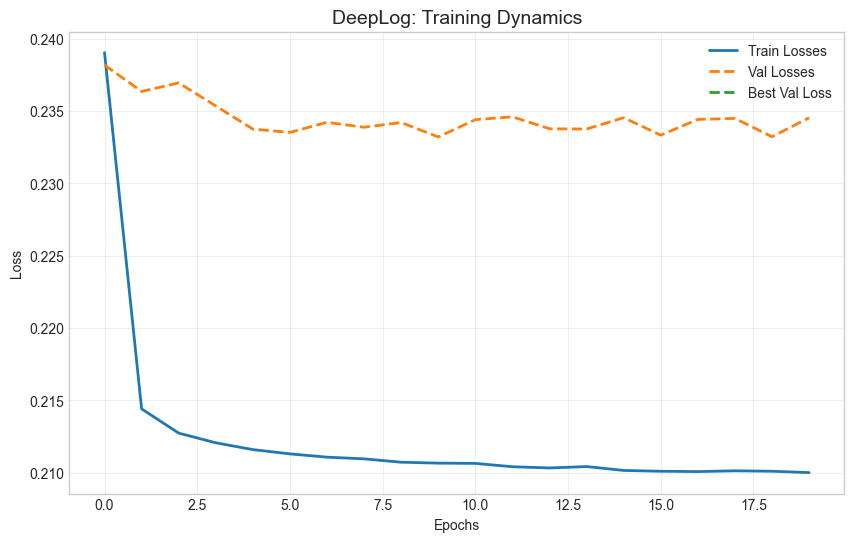

✓ Saved: ../../figures/deeplog/confusion_matrix.png


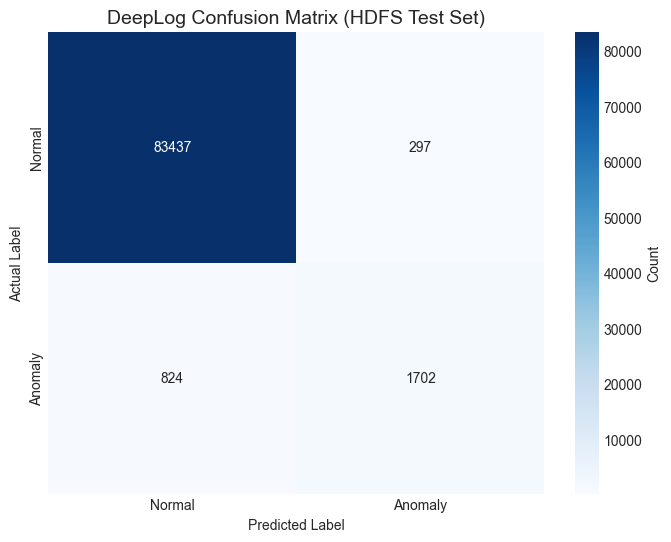

✓ Saved: ../../figures/deeplog/anomaly_score_distribution.png


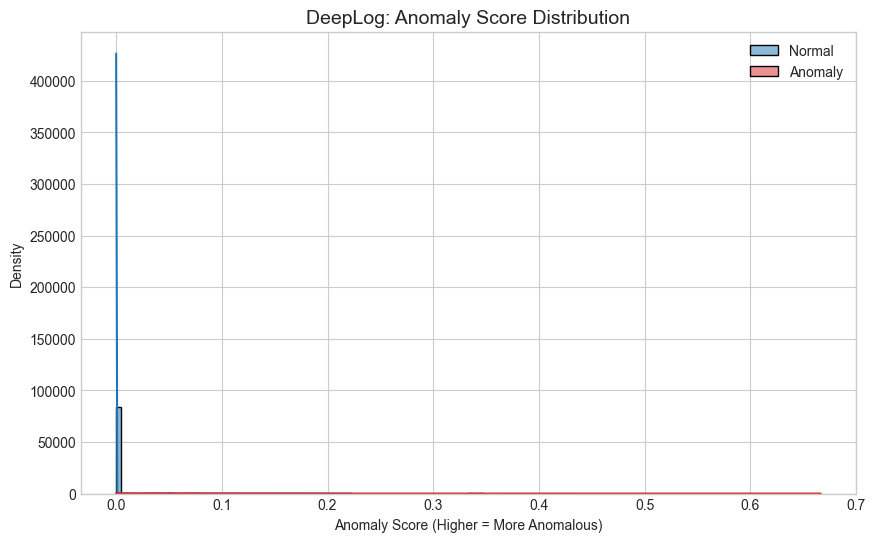

✓ Saved: ../../figures/deeplog/roc_curve.png


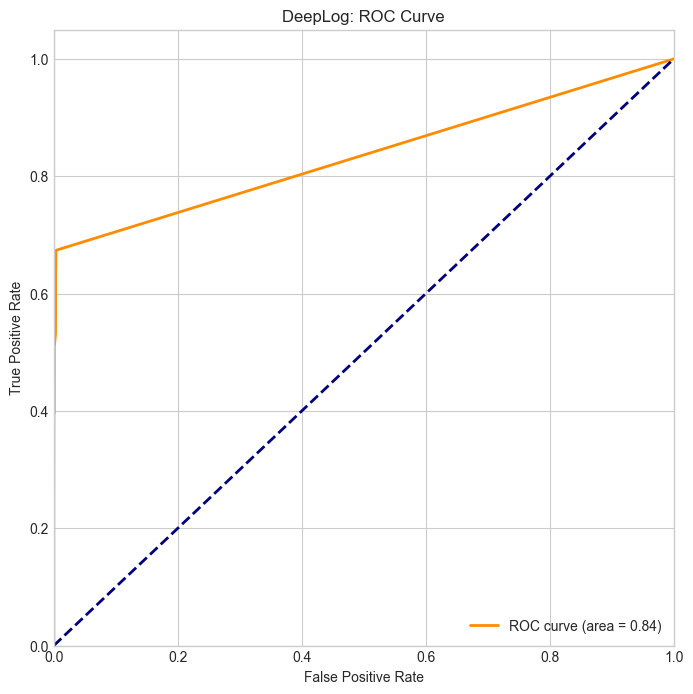

✓ Saved: ../../figures/deeplog/precision_recall_curve.png


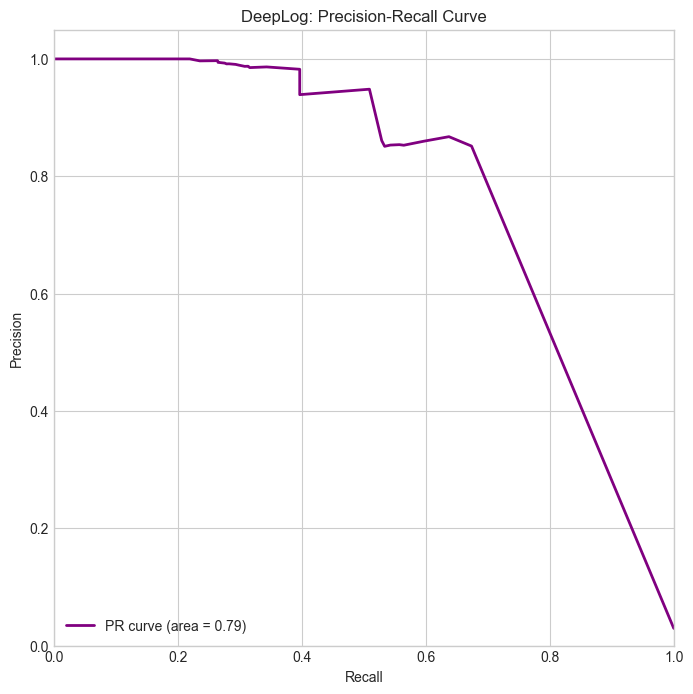


✓ All visualizations generated and saved using UniversalAnomalyVisualizer


In [12]:
### 6. Visualizations
viz = UniversalAnomalyVisualizer(model_name="DeepLog", save_dir="../../figures/deeplog")

# Plot 1: Training History (Loss curves)
viz.plot_training_history(history)

# Plot 2: Confusion Matrix
viz.plot_confusion_matrix(true_labels, predictions, title_suffix="(HDFS Test Set)")

# Plot 3: Anomaly Score Distribution
viz.plot_anomaly_score_distribution(true_labels, anomaly_scores, bins=50)

# Plot 4: ROC Curve
viz.plot_roc_curve(true_labels, anomaly_scores)

# Plot 5: Precision-Recall Curve
viz.plot_precision_recall_curve(true_labels, anomaly_scores)

print("\n✓ All visualizations generated and saved using UniversalAnomalyVisualizer")

In [ ]:
#  Save results
save_experiment_results(
    filepath="../../results/hdfs_deeplog_results.json",
    dataset="HDFS",
    model_name="DeepLog",
    device=device,
    model=model,
    history=history,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    max_len=max_len,
    metrics=metrics,
    batch_size=batch_size,
    learning_rate=learning_rate,
    patience=patience,
    top_k=top_k
)

✓ Results saved to ../../results/hdfs_deeplog_results.json


{'dataset': 'HDFS',
 'model': 'DeepLog',
 'device': 'mps',
 'architecture': {'vocab_size': 29,
  'embedding_dim': 64,
  'hidden_dim': 128,
  'num_layers': 2,
  'dropout': 0.3},
 'training': {'num_epochs': 20,
  'batch_size': 64,
  'learning_rate': 0.001,
  'early_stopping_patience': 10,
  'best_val_loss': 0.2332093509726602,
  'training_time_seconds': 718.5181679725647},
 'data': {'train_size': 390756,
  'val_size': 86259,
  'test_size': 86260,
  'max_sequence_length': 28,
  'train_normal_only': True},
 'detection': {'top_k': 4, 'method': 'next_event_prediction'},
 'metrics': {'accuracy': 0.9870044052863436,
  'precision': 0.8514257128564282,
  'recall': 0.6737925574030087,
  'f1': 0.7522651933701657,
  'confusion_matrix': [[83437, 297], [824, 1702]]}}

In [15]:
save_dir = Path('../../mdls')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'deeplog_hdfs_checkpoint.pt'
trainer.save_model(str(save_path))

✓ Model saved to ../../mdls/deeplog_hdfs_checkpoint.pt
